<h2>Google Play Store – Most Downloaded Apps Analysis</h2>

<p>Analyze Google Play Store data to:</p>
<ul>
    <li>Identify most downloaded apps</li>
    <li>Understand app distribution across categories</li>
    <li>Explore factors affecting downloads (rating, size, price, etc.)</li>
</ul>

<h3>Step 1:Import Libraries and Load Dataset</h3>

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv("google_play_store_most_downloaded_apps.csv") 

df.head()
#df.tail()

,App,Developer,Downloads,Date_Reached,Date_Published,Category,Pre_installed,Type,Price
0,Google Play Services,Google,10B+,2020-08-01,2012-09-26,Tools,Yes,Free,NaN
1,YouTube,Google,10B+,2021-08-04,2010-10-20,Video editor & social media,Yes,Free,NaN
2,Google Maps,Google,10B+,2021-11-16,2012-12-12,Mapping,Yes,Free,NaN
3,Speech Services by Google,Google,10B+,2021-11-18,2013-10-10,Accessibility tool,Yes,Free,NaN
4,Google Search,Google,10B+,2021-11-19,2010-08-12,Search tool,Yes,Free,NaN


In [72]:
df.tail()

,App,Developer,Downloads,Date_Reached,Date_Published,Category,Pre_installed,Type,Price
82,Terraria,505 Games Srl.,1M-5M,2016-02-20,2013-09-25,Games & adventure,No,Paid,4.99
83,Tasker,joaomgcd,1M-5M,2016-08-01,2010-07-03,Tools,No,Paid,3.49
84,Goat Simulator,Coffee Stain Publishing,1M-5M,2017-01-11,2014-09-16,Games & simulation,No,Paid,6.99
85,Stardew Valley,Chucklefish Limited,1M-5M,2020-10-01,2019-03-14,Games & role-playing,No,Paid,4.99
86,Monument Valley 2,ustwo games,1M-5M,2020-04-01,2017-11-06,Games & puzzle,No,Paid,3.99


<h3>Step 2: Understand data</h3>

In [66]:
df.describe()

,App,Developer,Downloads,Date_Reached,Date_Published,Category,Pre_installed,Type,Price
count,87,87,87,87,87,87,86,87,87
unique,87,46,7,77,82,51,2,2,9
top,Google Play Services,Google,1B-5B,2020-10-01,Unknown,Communication,No,Free,0
freq,1,32,24,3,4,13,47,66,66


In [64]:
df.columns

Index(['App', 'Developer', 'Downloads', 'Date_Reached', 'Date_Published',
       'Category', 'Pre_installed', 'Type', 'Price'],
      dtype='object')

In [62]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87 entries, 0 to 86
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   App             87 non-null     object
 1   Developer       87 non-null     object
 2   Downloads       87 non-null     object
 3   Date_Reached    87 non-null     object
 4   Date_Published  87 non-null     object
 5   Category        87 non-null     object
 6   Pre_installed   86 non-null     object
 7   Type            87 non-null     object
 8   Price           87 non-null     object
dtypes: object(9)
memory usage: 6.2+ KB


In [70]:
df.shape

(87, 9)

<h3>Step 3: Data Cleaning</h3>

<h4>3.1 Clean Price</h4>

In [56]:
df['Price'] = df['Price'].str.replace('$', '',regex=False)
df['Price']

0        0
1        0
2        0
3        0
4        0
      ... 
82    4.99
83    3.49
84    6.99
85    4.99
86    3.99
Name: Price, Length: 87, dtype: object

<h4>3.2 Handle Free Apps Price to $0</h4>

In [60]:
df['Price'] = df['Price'].fillna('0')
df['Price']

0        0
1        0
2        0
3        0
4        0
      ... 
82    4.99
83    3.49
84    6.99
85    4.99
86    3.99
Name: Price, Length: 87, dtype: object

<h4>3.3 Convert Installs to Numeric</h4>

In [82]:
def convert_installs(x):
    
    x = x.replace(',', '').strip()
    
    
    if '-' in x:
        low, high = x.split('-')
        return (convert_installs(low) + convert_installs(high)) / 2
    
    
    if 'B' in x:
        return float(x.replace('B', '').replace('+','')) * 1e9
    
    
    if 'M' in x:
        return float(x.replace('M', '').replace('+','')) * 1e6
    
    
    if 'K' in x:
        return float(x.replace('K', '').replace('+','')) * 1e3
    
    
    if '+' in x:
        return float(x.replace('+',''))
    
   
    return None

df['Installs_Num'] = df['Downloads'].apply(convert_installs)
df['Installs_Num']

0     1.000000e+10
1     1.000000e+10
2     1.000000e+10
3     1.000000e+10
4     1.000000e+10
          ...     
82    3.000000e+06
83    3.000000e+06
84    3.000000e+06
85    3.000000e+06
86    3.000000e+06
Name: Installs_Num, Length: 87, dtype: float64

<h3>Analysis</h3>

In [89]:
df['Type'].value_counts()

Type
Free    66
Paid    21
Name: count, dtype: int64

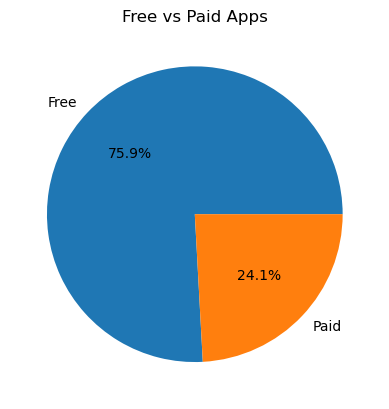

In [99]:
df['Type'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Free vs Paid Apps")
plt.ylabel("")
plt.show()